# NGC 1300 Nebular Spectroscopy

In this notebook, we will walk through how to display, fit, and analyze emission spectra from nebular regions in NGC 1300. Throughout the notebook, there will be semi-complete blocks of code which you will have to fill in. You will be introduced to the methods used before needing to implement them yourself. 

Comments will be included throughout the code to explain what each line does. These will be denoted with either red strings (' ') or #

Please do not hesitate to ask for help along the way! Now let's get started!

# Part 1

## Imports
Every notebook should start with your imports. This will make all of the packages and tools you need available from the very start of your code. 

In [1]:
import numpy as np # all of the basic math/computation tools you need
import matplotlib.pyplot as plt # all of the plotting tools you need
import astropy # astronomy-specific package
from astropy.io import fits # allows you to easily open fits files

## Opening the spectra
Now that we have the necessary tools for now, let's access and open the data so we will be working with. If this notebook is stored within OneDrive, the files in the folder should be accessible and there is no need to download them. Otherwise, you will need to change the file paths used in this notebook. 

Fits files are opened as Header Data Units (HDU). This HDU contains the header (all of the information about the coordinate system, units, observing techniques, etc.) and the data. 

For this fits file, there are 2 HDUs: the first one containing the flux values, and the second containing the wavelength information. The organization of this file is outline in the associated ReadMe, which is available in the OneDrive folder. Formatting varies a lot between datasets, so having a ReadMe file is important. 

Let's open the data.

In [2]:
# The spectra for NGC1300 are located in the file named 'NGC1300_VorSpectra.fits'
#hdu=fits.open('Polaris-2026/spectra/NGC1300_VorSpectra.fits')
hdu=fits.open('NGC1300_VorSpectra.fits')

# Here's how we can access the flux information
flux=hdu[1].data['SPEC']


# and the wavelength
wave_log=hdu[2].data['LOGLAM']

# The file has log(wavelength) so we will undo that to put it back to linear
wave=np.exp(wave_log)
print("Data for NGC1300 has been read.")

Data for NGC1300 has been read.


Okay great, now we've read the data and are ready to play around with it. Let's see what it looks like.

In [3]:
print('Shape of Flux:',np.shape(flux))
print('Shape of Wave:',np.shape(wave))

Shape of Flux: (1478, 3835)
Shape of Wave: (3835,)


This tells us that there are 1478 regions with spectra in this file. Each spectra consists of 3835 wavelengths and 3835 corresponding flux values. We will NOT be dealing with all 1478 of those regions, we will just focus on two: 961 and 684. To access these, we need to 'index' the flux array for the index number we want with flux[_ ID _]

Let's define a variable so we can keep things straight and not remember two random numbers.

In [4]:
# These are the region numbers that we will be using throughout the project
region1=961
region2=684
print(flux[961])
print(wave[961])

print(flux[684])
print(wave[684])

[388.09455826 396.172586   406.17867726 ... 415.1289987  395.42421822
 378.03214836]
5663.500316192432
[538.11497434 604.79737443 687.39552858 ... 323.69782954 323.19242782
 318.33054794]
5407.806210836271


## Plotting the spectra

Now for the fun part, we get to plot the data! 

You can change the properties of the plotted line using keywords like:

linewidth (or lw): changes the width of the line, default is 1.5

color: can be a matplotlib default color or an xkcd color name written as a string like 
'xkcd:red' https://xkcd.com/color/rgb/

These are the most common, but there are many more customizations in the matplotlib documentation: 
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

To save the image, we include 'plt.savefig()' as the final line before 'plt.show()'. 

### Play around with some of these features to get a full spectrum of Region 1 you are really happy with! Have fun with it!

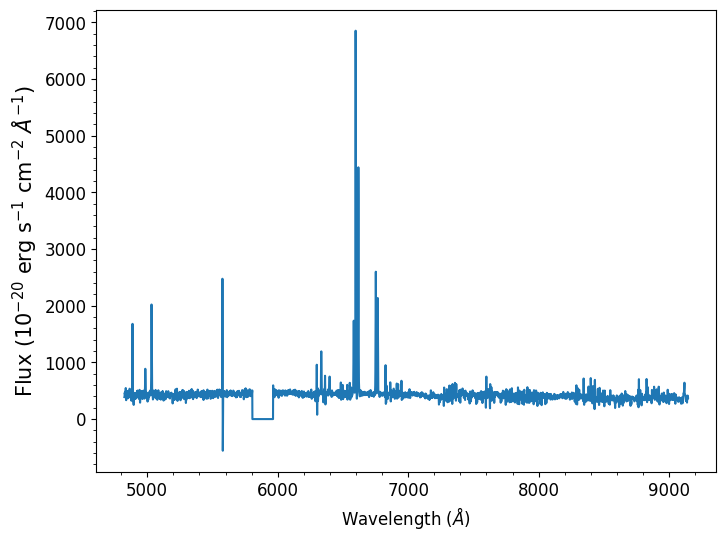

In [5]:
plt.figure(figsize=(8,6))
plt.plot(wave, flux[region1])
 #plot a line given x, y
plt.gca().minorticks_on()
plt.gca().tick_params(labelsize=12)
plt.xlabel(r'Wavelength ($\AA$)',fontsize=12)
plt.ylabel(r'Flux ($10^{-20}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)',fontsize=15)
plt.savefig('full_spec_of_r1.jpg',bbox_inches='tight') # including no file path here saves the figure in the same location as the notebook.
    # bbox_inches controls how much white space is around the saved figure. I always include this
plt.show()


# Part 2

## Identifying emission lines

In this spectra, it is pretty clear where the emission lines are, but how do we know what type of gas they come from? The short answer is that you typically have a list of a whole bunch of emission lines that are commonly seen. So you always just look for those. 

Here is a dictionary linking the emission line to its wavelength (in Angstroms). 

In [6]:
em_lines={'Hb':4861,'OIII_1':4959,'OIII_2':5007,'OI':6300,'Ha':6562,'NII_1':6548,'NII_2':6584,'SII_1':6717,'SII_2':6731}


Some of the emission lines have a '_1' and '_2' in them. This means that it's a doublet. They are produced by the same energy transition of the electron, but the wavelength changes because of the electron spin. So their typical strength is set by quantum mechanics. We almost always combine their strengths because of this.

There are also emission lines produced by the atomosphere of Earth. These are also at extremely predictable wavelengths (and their redshift is zero) so we just need to mask those out, or ignore them in the analysis. 

Here are a couple big ones in the wavelength range we care about:

In [7]:
sky_lines=[5577,6300,6363]

Now that we've identified where the emission lines are expected to be, We can plot and label them on our figure from before. 
You may have notices that there is quite a large spread in wavelength for the prominent emission lines, but they do come in convenient groups. So we'll also make a subplot so that we can display two sections of the spectra at the same time. 

In this block, we will build code to make a really pretty spectrum of Region 1 with all emission lines labeled. Use whatever customizations you want to make this how you want it to be.

<>:8: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:11: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:8: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:11: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
C:\Users\mya\AppData\Local\Temp\ipykernel_952\71271523.py:8: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
  ax.set_xlabel('Wavelength ($\AA$)',fontsize=12)
C:\Users\mya\AppData\Local\Temp\ipykernel_952\71271523.py:11: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences 

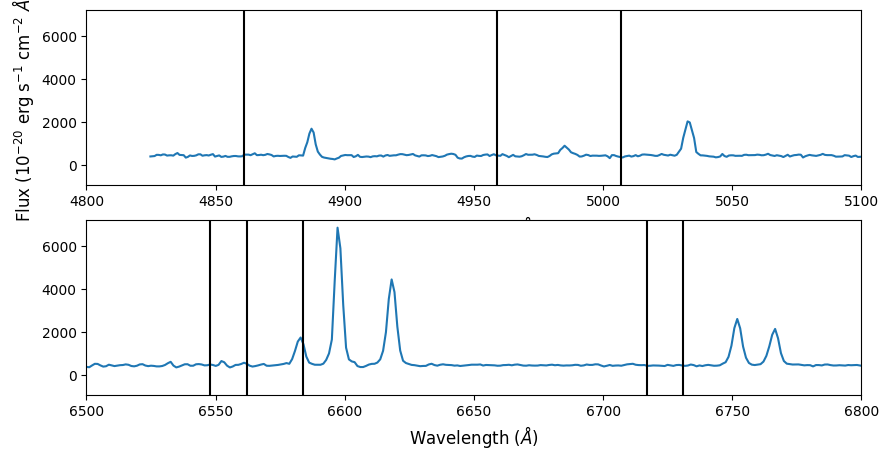

In [12]:
fig,axs=plt.subplots(2,figsize=(10,5))
for ax in axs:
    ax.plot(wave, flux[region1])
    for l,line in enumerate(em_lines):
        ax.axvline(em_lines[line],label=f'{line}',color='k')
    for s in sky_lines:
        ax.axvline(s,color='gray')
    ax.set_xlabel('Wavelength ($\AA$)',fontsize=12)
axs[0].set_xlim(4800,5100)
axs[1].set_xlim(6500,6800)
axs[0].set_ylabel('Flux ($10^{-20}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)',fontsize=12)
plt.show()

Why don't our vertical lines match with the observed emission?

Well, the galaxy we're looking at is pretty far away. It's very close in the grand scheme of things, but it's far enough to cause a redshift in the emission. The x axis of this spectrum is actually the "observed" wavelength. What we really want is the "emitted" wavelength or "rest" wavelength before the light was redshifted. 

Let's write a function that will correct for the redshift of the galaxy. 

In [16]:
def lam_obs(lam_rest,z):
    ''' convert a rest wavelength to the observed wavelength at a given redshift '''
    lam=z*lam_rest+lam_rest
    return lam


Amazing. We can now convert the rest wavelength of the emission lines to the observed wavelength in the spectrum. 

But we actually don't know the redshift of the galaxy. Google could tell us, but we would need to keep googling things if we ever wanted to change the galaxy we look at. So let's write some code to convert the distance of the galaxy (which is something that has been calculated precisely for every PHANGS galaxy) to the redshift. 

In [17]:
import astropy.units as u
import astropy.cosmology.units as cu
from astropy.cosmology import FlatLambdaCDM
u.add_enabled_units(cu)

D=21*u.Mpc # Distance to NGC 1300 from the PHANGS sample table
cosmo = FlatLambdaCDM(H0=70, Om0=0.3, Tcmb0=2.725)
z=D.to(cu.redshift,cu.with_redshift(cosmo, distance="comoving"))
print(f'Distance = {D}, z = {z.value}')


Distance = 21.0 Mpc, z = 0.0049088217264950055


Now that we have that, let's retry the plot. 

Here, the code is written so that the emission line wavelengths are redshifted to the distance of the galaxy, observed wavelength on the x axis. Try making a plot with rest wavelength on the x axis by correcting the observed wavelength array instead of the emission lines. 

<>:8: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:11: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:8: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:11: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
C:\Users\mya\AppData\Local\Temp\ipykernel_952\3452307193.py:8: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
  ax.set_xlabel('Wavelength ($\AA$) (rest wavelength)', fontsize=12)
C:\Users\mya\AppData\Local\Temp\ipykernel_952\3452307193.py:11: SyntaxWarning: "\A" is an invalid escape se

Spectrum of Region 1 (with Emission Lines Labeled)


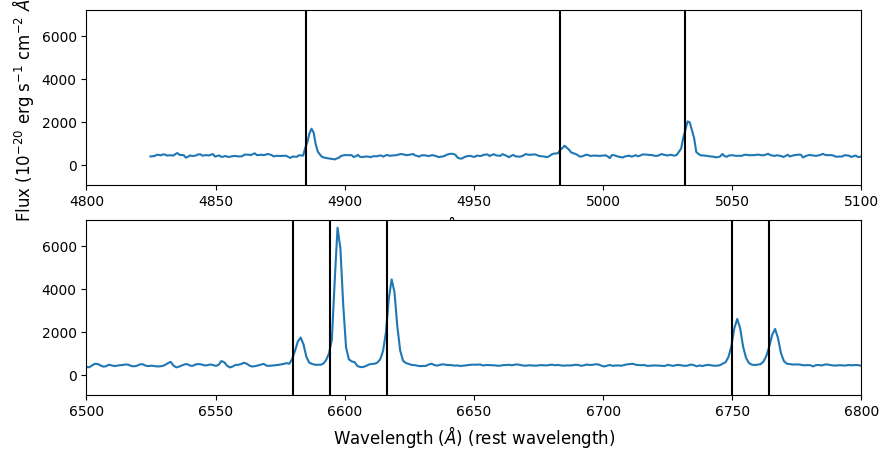

In [ ]:
fig,axs=plt.subplots(2,figsize=(10,5))
for ax in axs:
    ax.plot(wave, flux[region1])
    for l,line in enumerate(em_lines):
        ax.axvline(lam_obs(em_lines[line],z),label=f'{line}',color='k') 
        # correcting for redshift
    for s in sky_lines:
        ax.axvline(s,color='gray') # we don't need to correct these, because they are redshift 0
    ax.set_xlabel('Wavelength ($\AA$) (rest wavelength)', fontsize=12)
axs[0].set_xlim(4800,5100)
axs[1].set_xlim(6500,6800)
axs[0].set_ylabel('Flux ($10^{-20}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)', fontsize=12)
plt.savefig('spec_of_r1_w_emlines_labeled.jpg',bbox_inches='tight')
print('Spectrum of Region 1 (with Emission Lines Labeled)')
plt.show()

It worked! Much better! Any shifts that are not fixed by the redshift correction could be arising from several different places:

1. There could be a velocity shift. When an object is moving towards us, it is blue-shifted to shorter wavelengths and when the object is moving away from us, it is red-shifted to longer wavelengths. If gas is moving fast enough, this can make a huge difference.
2. There could be any number of uncertaintines along the way, from the distance calculation, to the cosmology used, to the expected wavelength of the emission. All of this makes some difference, in certain cases more and others less. 

Now that we have some working code for Region 1, repeat the same plot for Region 2. Make sure to save both figures. 

### Plotting Data for Region 2

<>:10: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:13: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:10: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:13: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
C:\Users\mya\AppData\Local\Temp\ipykernel_952\1384876635.py:10: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
  ax.set_xlabel('Wavelength ($\AA$) (rest wavelength)', fontsize=12)
C:\Users\mya\AppData\Local\Temp\ipykernel_952\1384876635.py:13: SyntaxWarning: "\A" is an invalid escape

Spectrum of Region 2 (with Emission Lines Labeled)


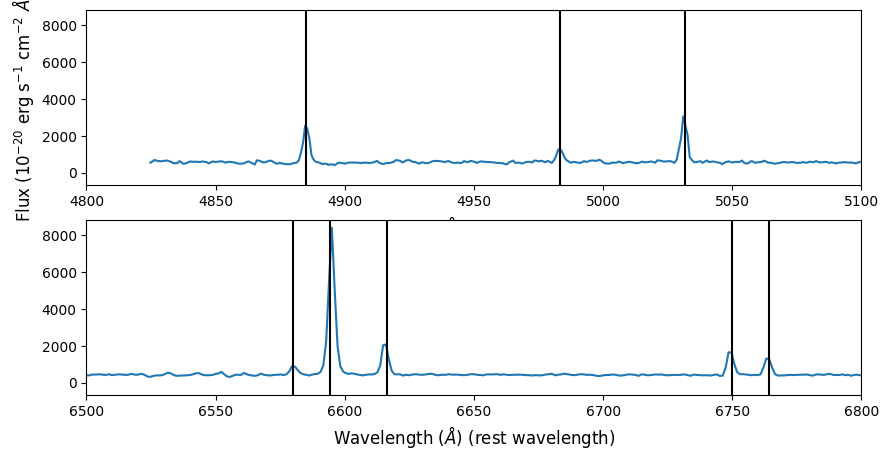

In [59]:
# Write plotting code for Region 2 here. 
fig,axs=plt.subplots(2,figsize=(10,5))
for ax in axs:
    ax.plot(wave, flux[region2])
    for l,line in enumerate(em_lines):
        ax.axvline(lam_obs(em_lines[line],z),label=f'{line}',color='k')
         # correcting for redshift
    for s in sky_lines:
        ax.axvline(s,color='gray') # we don't need to correct these, because they are redshift 0
    ax.set_xlabel('Wavelength ($\AA$) (rest wavelength)', fontsize=12)
axs[0].set_xlim(4800,5100)
axs[1].set_xlim(6500,6800)
axs[0].set_ylabel('Flux ($10^{-20}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)', fontsize=12)
plt.savefig('spec_of_r2_w_emlines_labeled.jpg',bbox_inches='tight')
print('Spectrum of Region 2 (with Emission Lines Labeled)')
plt.show()


### What do you notice about these spectra when comparing Region 1 and Region 2?

Region 1 has more emission lines than Region 2, but they both have an emission line at around 6584 nm, indicating that NII is in both regions (?).

# Part 3

In parts 1 and 2, we plotted the spectra of two nebular regions and plotted the emission lines on top of them. No we want to actually find out what these nebular regions are, what physical processes are producing this emission. 

We will do this using BPT diagrams. These diagrams use emisison line ratios to constrain the strength and intensity of the radiation producing the emission. By measuring the strength of the emission lines, and comparing their ratios to those of known nebular regions, we can determine exactly what each region is. 

So let's get started!

## Fitting Emission Lines

Someone has spent a really long time trying to get the best fits to the emission lines of all 18,000+ nebular regions in the PHANGS galaxies. We will reference their work, but also simplify it for this project. 

We will measure the flux of the emission lines by fitting each one with a Gaussian profile. The first step is to create a function for a Gaussian:
$$y=Ae^{-(x-x_0)^2/(2\sigma^2)}+c$$
where $A$ is the amplitude of the Gaussian, $x_0$ is the central wavelength, and $\sigma$ is the width (standard deviation). We add a continuum flux value as $c$ since the continuum emission has not been subtracted.

Now we create a python function that takes in a wavelength array and values for $A$, $x_0$, $\sigma$, and $c$ and returns the y values of the resulting Gaussian:

In [30]:
def gaussian(x,A,x0,sigma,c):
    ''' function that takes in wavelength array and parameters to return the y values for gaussian ''' 
    y = A * np.exp(-((x-x0)**2) / (2 * sigma**2)) + c#can i use math.exp?? hopefully - update: no i cannot 
    return y

One more thing. Instead of constantly converting the wavelengths of the emission lines to the observed wavelengths because of the redshift, we will just shift the whole spectrum and just correct the wavelength array. Now, when we plot with wave_rest, we have the redshift-corrected, emitted wavelength on the x axis.



In [28]:
# invert the lam_obs function
    
def lam_rest(lam_obs,z):
    ''' convert an observed wavelength to the rest wavelength at a given redshift '''
    lam = lam_obs / (1 + z)
    return lam
wave_rest = lam_rest(wave, z)

#wave_rest=lam_rest(lam_obs,z): wouldn't let me run with lam_obs as parameter, so I changed it to wave? That worked but I'm not sure why. \

Now that we have that function, we can use it to fit the emission lines of both of our regions. We will do this using scipy.optimize.curve_fit: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html 

This function takes in a function you want to fit the data with, x values and y values for the data you want to fit, and returns two things: 

1. The first is called 'popt', which is an array that contains the optimal input parameters for your function.
2. The second is called 'pcov' which is a covariance matrix for the best-fit parameters, basically it's the errors on the parameter values.

So every time we run curve_fit, we need to save two things. 

We also want to make sure we're only fitting the lines we're interested, so we will create a wavelength index to limit the amount of data we put into the fit. About 10 Angstroms should do. In reality, we should probably do a simultaneous fit to all the lines because they have ~the same source and their continuum fluxes are linked, velocities are not independent, etc. But I said we're keeping things simple, and we only have 2 regions not 18,000, which means we'll do everything one at a time. 

Okay, finally let's fit!

In [31]:
# Fit the H-alpha emission line for Region 1
from scipy.optimize import curve_fit
# limit the data range to only include the Ha emission line
ha_index=(wave_rest<6572)&(wave_rest>6552)
# fit the data within ha_index
# index of wavelengths between two lines, one emission line is best for gaussian fitting
popt_ha_1,pcov_ha_1=curve_fit(gaussian,wave_rest[ha_index],flux[region1][ha_index])
# print popt so we can see what it contains
print(popt_ha_1)

[1.0000000e+00 1.0000000e+00 1.0000000e+00 1.7066137e+03]


C:\Users\mya\AppData\Local\Temp\ipykernel_952\225862251.py:7: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_ha_1,pcov_ha_1=curve_fit(gaussian,wave_rest[ha_index],flux[region1][ha_index])


When we print 'popt', we see that it's an array with four entries. Each of these is a different parameter for the Gaussian, in the order that they are listed in your function. We defined it as A,x0,sigma,c so

A = 1, x0 = 1, sigma = 1, c = 1.71E3

Now let's see what it actually looks like. To plot the fit, we just use an arbitrary x array (to get a smooth curve you want a lot of points) which we'll use np.linspace(start,stop,number) to define. We input that x array into the function we used to fit, along with all of the fit parameters. So,

plt.plot(np.linspace(start,stop,number),gaussian(np.linspace(start,stop,number),popt[0],popt[1],popt[2],popt[3]))

We need to list all of the parameters in the array because the order matters. But that's annoying if there are a bunch of parameters in your fit. So instead of listing all of them like that, we use this shortcut:

*popt

This tells the function that this is a list and the list contains all of the parameters for the function so use every entry as one parameter. So we end up with:

plt.plot(np.linspace(start,stop,number),gaussian(np.linspace(start,stop,number),*popt))

Now let's plot it.

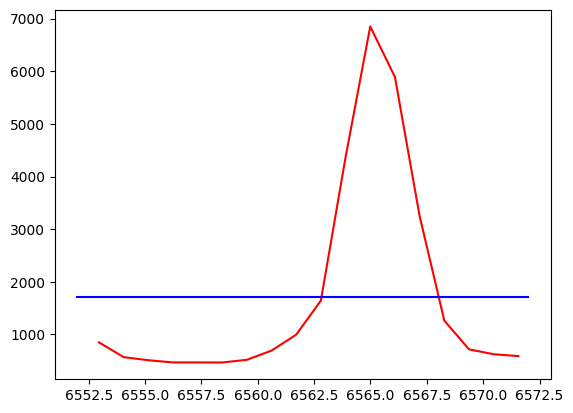

In [32]:
# plot the actual data
plt.plot(wave_rest[ha_index],flux[region1][ha_index],color='r')
# plot the fit with some arbitrary x values and the best fit parameters
plt.plot(np.linspace(6552,6572,1000),gaussian(np.linspace(6552,6572,1000),*popt_ha_1),color='b') # plot the fit
plt.show()

Well that looks terrible...

We should probably help this fitting function out a little bit! We'll use the keyword 'p0' to initialize the fit with some parameter guesses and try again.

'p0' allows us to give a guess at what each of the parameters is. So looking at the emission line we just printed, we can just say maybe

A = 7000,
x0 = 6565,
sigma = 2, 
c = 1000

You don't need to be exact, you don't even need to be very close all the time, but this keeps the function from starting with A=1 when we tell it to start much higher. So we'll add in a new p0 term in our fit and see how that looks.

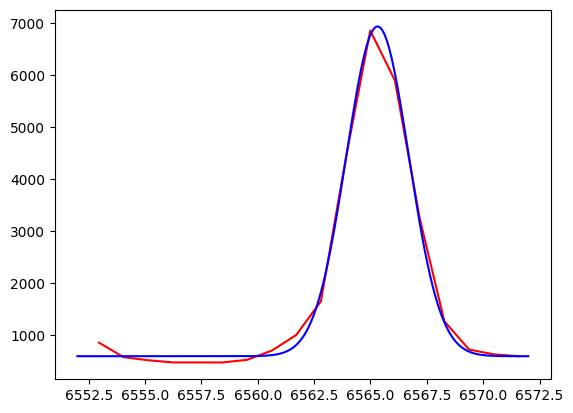

In [33]:
# Fit the H-alpha emission line for Region 1
from scipy.optimize import curve_fit
ha_index=(wave_rest<6572)&(wave_rest>6552)
popt_ha_1,pcov_ha_1=curve_fit(gaussian,wave_rest[ha_index],flux[region1][ha_index],p0=[7000,6562,3,1000])
plt.plot(wave_rest[ha_index],flux[region1][ha_index],color='r')
plt.plot(np.linspace(6552,6572,1000),gaussian(np.linspace(6552,6572,1000),*popt_ha_1),color='b')
plt.show()

Much better! We can also constrain the fit even more by forcing bounds on the parameters. If I _know_ A and sigma should be positive, I can require that. But you have to define bounds for all of the parameters, unfortunately you can't just pick and choose. But if you really don't care what c is, you can say the limits are -np.inf to np.inf. That way it can still pick whatever it wants. 

We use the keyword 'bounds' for this, and add it to the curve_fit function just like p0. As an example, 

bounds=(lower_limits,upper_limits)

bounds=((p0_min,p1_min,p2_min,p3_min),(p0_max,p1_max,p2_max,p3_max))

### Try adding some bounds of parameters and see how things change the fit. Can you get it any better than the default?

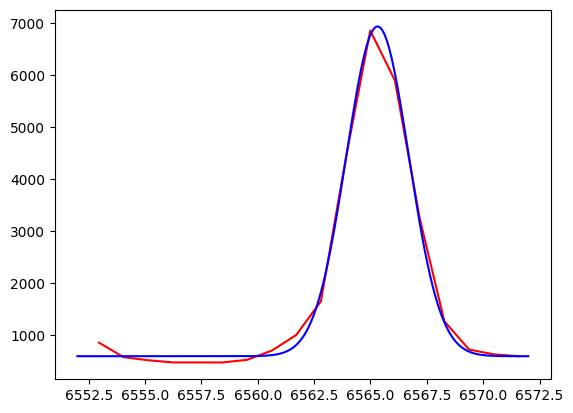

In [34]:
# refit and replot the H-alpha emission line with bounds
ha_index=(wave_rest<6572)&(wave_rest>6552)
popt_ha_1,pcov_ha_1=curve_fit(gaussian,wave_rest[ha_index],flux[region1][ha_index],p0=[7000,6562,3,1000],
bounds=((0,0,0,0),(np.inf,np.inf,np.inf,np.inf)))
plt.plot(wave_rest[ha_index],flux[region1][ha_index],color='r')
plt.plot(np.linspace(6552,6572,1000),gaussian(np.linspace(6552,6572,1000),*popt_ha_1),color='b')
plt.show()

Now let's try the rest of the emission lines and make a cool plot. To maximize efficiency, we don't want to just copy and paste and copy and paste and keep changing the tiny details. So we'll also do this in a loop and save the output in a dictionary. That way we can reference the fits again later without having to rerun every single fit or remember exactly what we named every individual value. Which you absolutely can do! But dictionaries are cool and useful. So let's get those set up.

We can add to this dictionary by indexing it with the key we want to add and setting that equal to the value or array we want. So something like 

em_popts_r1['keyword']=array

Then displaying the dictionary would now look like

em_popts_r1={'keyword':array}

array can be anything from a string to a list to a numpy array to a float. But for this case, we're just going to add the popt and pcov arrays for all of the emission lines we listed out earlier. 

### Hb Fit

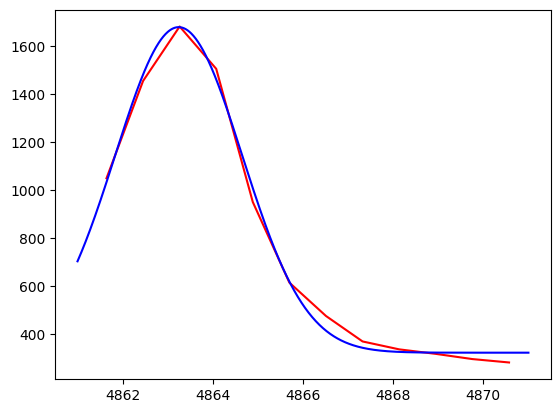

In [21]:
hb_index=(wave_rest<4871)&(wave_rest>4861)
popt_ha_1,pcov_ha_1=curve_fit(gaussian,wave_rest[hb_index],flux[region1][hb_index],p0=[5000,4856,3,1000],
bounds=((0,0,0,0),(np.inf,np.inf,np.inf,np.inf)))
plt.plot(wave_rest[hb_index],flux[region1][hb_index],color='r')
plt.plot(np.linspace(4861,4871,1000),gaussian(np.linspace(4861,4871,1000),*popt_ha_1),color='b')
plt.show()
# em_lines={'Hb':4861,'OIII_1':4959,'OIII_2':5007,'OI':6300,'Ha':6562,'NII_1':6548,'NII_2':6584,'SII_1':6717,'SII_2':6731}

### Fitting Emission Lines using a For Loop

#### Region 1

<>:8: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:23: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:8: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:23: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
C:\Users\mya\AppData\Local\Temp\ipykernel_952\3591831153.py:8: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
  plt.xlabel('Wavelength ($\AA$) (rest wavelength)', fontsize=12)
C:\Users\mya\AppData\Local\Temp\ipykernel_952\3591831153.py:23: SyntaxWarning: "\A" is an invalid escape seque

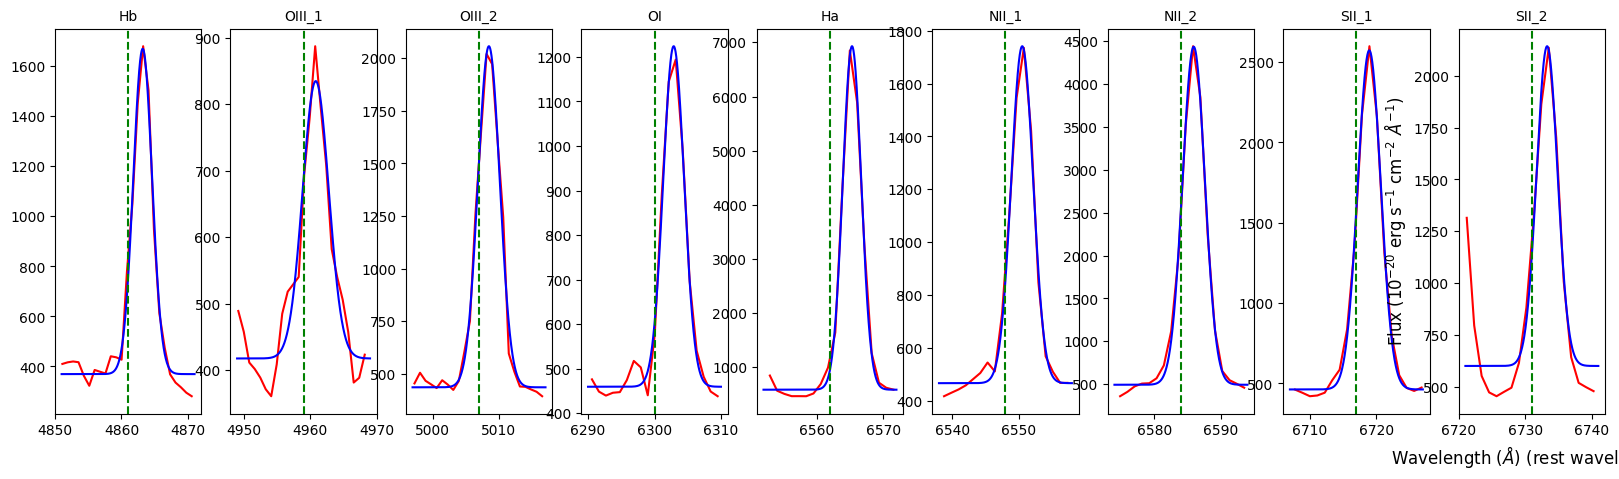

In [76]:
# Try fitting each line outside the for loop if you prefer
em_popts_r1={}
em_pcovs_r1={}

fig, axs = plt.subplots(1,len(em_lines), figsize=(20, 5)) #9 zoomed in plots for each line  (?)
#plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, #changed orientation with help from https://alejandrosoto.net/blog/2022-02-05-matplotlib-space-between-subplots/
                   # top=0.9, wspace=0.4,hspace=0.4) #update: this was not showing the gaussian distribution, too small
plt.xlabel('Wavelength ($\AA$) (rest wavelength)', fontsize=12)
            
for l,line in enumerate(em_lines):
    index= (wave_rest<(em_lines[line]+10))&(wave_rest>(em_lines[line]-10)) #range of all emission lines +-10
    # em_lines={'Hb':4861,'OIII_1':4959,'OIII_2':5007,'OI':6300,'Ha':6562,'NII_1':6548,'NII_2':6584,'SII_1':6717,'SII_2':6731}
    # fit the emission line
    popt,pcov=curve_fit(gaussian,wave_rest[index],flux[region1][index],p0=[7000, em_lines[line], 3, 1000])
    # save these parameters to our dictionary
    em_popts_r1[line]=popt
    em_pcovs_r1[line]=pcov
    # plot the emission linesem
    axs[l].plot(wave_rest[index],flux[region1][index],color='r')
    axs[l].plot(np.linspace(em_lines[line]-10,em_lines[line]+10,1000),gaussian(np.linspace(em_lines[line]-10,em_lines[line]+10,1000),*popt),color='b')
    axs[l].set_title(line,fontsize=10)
    axs[l].axvline(em_lines[line],color='g', ls='--')
plt.ylabel('Flux ($10^{-20}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)', fontsize=12) #when i tried plt.ylabel it moved 
plt.savefig('fitted_lines_region1.png')
plt.show()

Now the offset between the expected wavelength of the emission (gray line) and the observed wavelength is pretty obvious. Definitely interesting...

Let's repeat for Region 2.



#### Region 2

<>:8: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:22: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:8: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:22: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
C:\Users\mya\AppData\Local\Temp\ipykernel_952\4199269051.py:8: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
  plt.xlabel('Wavelength ($\AA$) (rest wavelength)', fontsize=12)
C:\Users\mya\AppData\Local\Temp\ipykernel_952\4199269051.py:22: SyntaxWarning: "\A" is an invalid escape seque

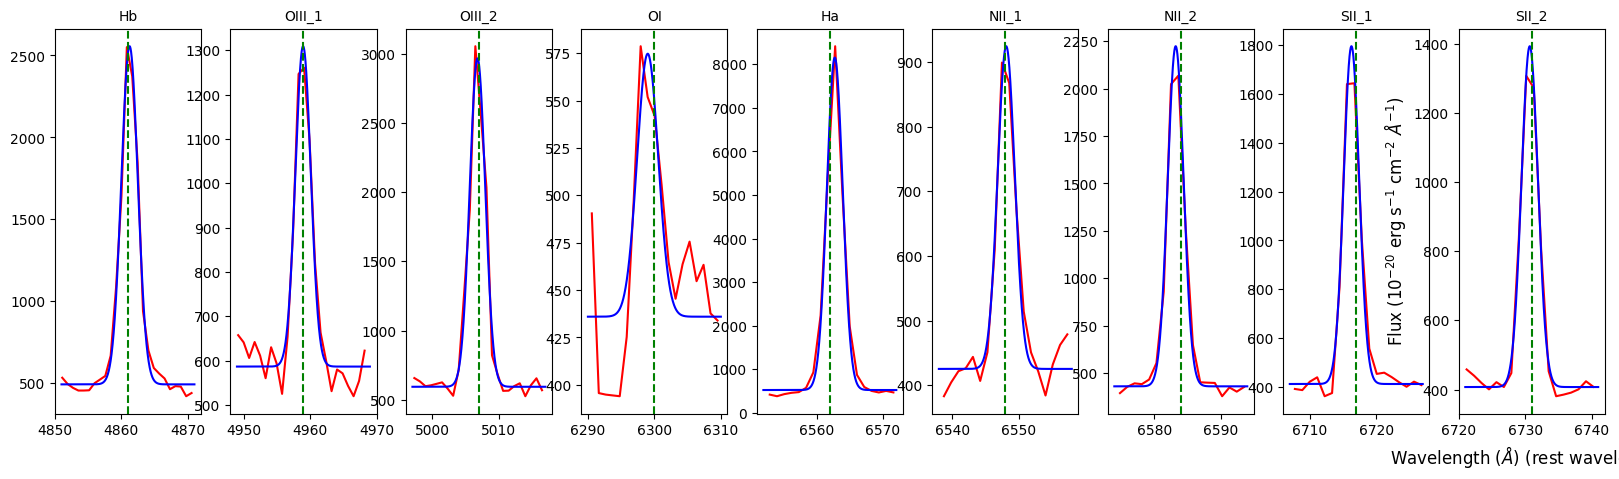

In [77]:
em_popts_r2={} #dictionaries for region 2
em_pcovs_r2={}
# Repeat plot for region 2
# don't forget the new dictionaries
fig, axs = plt.subplots(1, len(em_lines), figsize=(20, 5)) #9 plots for each line
#plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, #changed orientation with help from https://alejandrosoto.net/blog/2022-02-05-matplotlib-space-between-subplots/
                    #top=0.9, wspace=0.4,hspace=0.4) 
plt.xlabel('Wavelength ($\AA$) (rest wavelength)', fontsize=12)
for l,line in enumerate(em_lines):
    index= (wave_rest<(em_lines[line]+10))&(wave_rest>(em_lines[line]-10)) #range of all emission lines +-10
    # em_lines={'Hb':4861,'OIII_1':4959,'OIII_2':5007,'OI':6300,'Ha':6562,'NII_1':6548,'NII_2':6584,'SII_1':6717,'SII_2':6731}
    # fit the emission line
    popt,pcov=curve_fit(gaussian,wave_rest[index],flux[region2][index],p0=[7000, em_lines[line], 3, 1000])
    # save these parameters to our dictionary
    em_popts_r2[line]=popt
    em_pcovs_r2[line]=pcov
    # plot the emission linesem
    axs[l].plot(wave_rest[index],flux[region2][index],color='r')
    axs[l].plot(np.linspace(em_lines[line]-10,em_lines[line]+10,1000),gaussian(np.linspace(em_lines[line]-10,em_lines[line]+10,1000),*popt),color='b')
    axs[l].set_title(line,fontsize=10)
    axs[l].axvline(em_lines[line],color='g', ls='--')
plt.ylabel('Flux ($10^{-20}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)', fontsize=12) #when i tried plt.ylabel it moved 
plt.savefig('fitted_lines_region2.png')
plt.show()


## Measuring Line Fluxes

Now that we have the best parameters to define each emission line as a Gaussian function, we can measure the total emitted flux at these wavelengths. 

The total emission under a Gaussian is just
$$F=\sqrt{2\pi}A\sigma$$
and we just measured $A$ and $\sigma$ so let's calculate the total fluxes for each emission line.

In [68]:
em_fluxes_r1={}
em_fluxes_r2={}

for l,line in enumerate(em_lines):
    A1=em_popts_r1[line][0]
    sigma1=em_popts_r1[line][2]
    flux1= np.sqrt(2 * np.pi) * A1 * np.abs(sigma1)
    em_fluxes_r1[line]=flux1 

    A2=em_popts_r2[line][0]
    sigma2=em_popts_r2[line][2]
    flux2= np.sqrt(2 * np.pi) * A2 * np.abs(sigma2)
    em_fluxes_r2[line]=flux2
    # repeat for Region 2: check 
print(flux1) #what does negative flux mean?
print(flux2)
    

3055.5016502695166
3055.5016502695166


# Part 4

## Identifying nebular type

Now we are FINALLY ready to figure out what these regions are!

Let's plot the N2-BPT diagram! That is, 

$$\rm  \log_{10}([OIII]\lambda 5007/H\beta)\ \ vs.\ \log_{10}([NII]\lambda 6584/H\alpha)$$

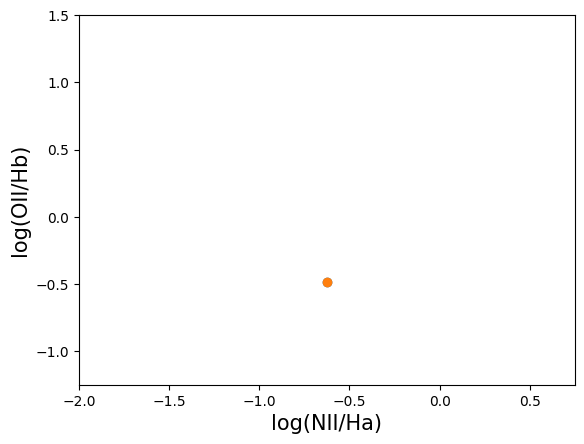

In [69]:
# Plot N2-BPT diagram
#x=np.log10(em_fluxes_r1['NII_2']/em_fluxes_r1['Ha'])
#y=np.log10(em_fluxes_r1['OIII_1']/em_fluxes_r1['Hb'])
#x1=np.log10(em_fluxes_r2['NII_2']/em_fluxes_r2['Ha'])
#y1=np.log10(em_fluxes_r2['OIII_1']/em_fluxes_r2['Hb'])
#plt.scatter(x,y) 
#plt.scatter(x1,y1)# plot region 1
plt.scatter(np.log10(em_fluxes_r1['NII_2']/em_fluxes_r1['Ha']), np.log10(em_fluxes_r1['OIII_1']/em_fluxes_r1['Hb'])) # plot region 1
plt.scatter(np.log10(em_fluxes_r2['NII_2']/em_fluxes_r2['Ha']), np.log10(em_fluxes_r2['OIII_1']/em_fluxes_r2['Hb'])) # plot region 2
plt.xlim(-2,0.75) # common limits for N2-BPT diagram
plt.ylim(-1.25,1.5) # common limits for N2-BPT diagram
plt.xlabel(r'log(NII/Ha)',fontsize=15)
plt.ylabel(r'log(OII/Hb)',fontsize=15)
plt.show()

And now the S2-BPT diagram.
$$\rm  \log_{10}([OIII]\lambda 5007/H\beta)\ \ vs.\ \log_{10}([SII]/H\alpha)$$

Remember that the "S2" part of this is actually the _sum_ of the two [SII] emission lines since it's a doublet. 

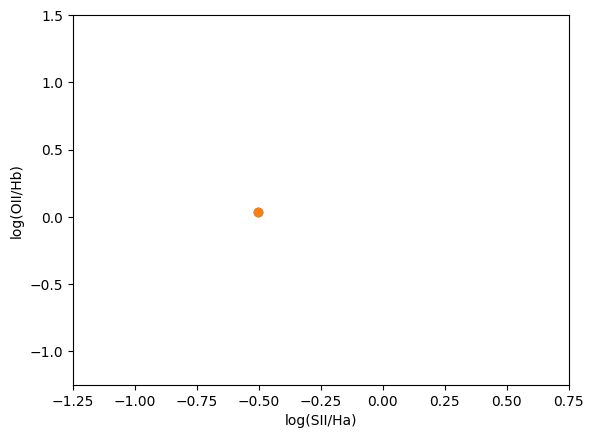

In [70]:
# Plot S2-BPT diagram
plt.scatter(np.log10((em_fluxes_r1['SII_1']+em_fluxes_r1['SII_2'])/em_fluxes_r1['Ha']), np.log10(em_fluxes_r1['OIII_2']/em_fluxes_r1['Hb'])) # plot region 1
plt.scatter(np.log10((em_fluxes_r2['SII_1']+em_fluxes_r2['SII_2'])/em_fluxes_r2['Ha']), np.log10(em_fluxes_r2['OIII_2']/em_fluxes_r2['Hb'])) # plot region 2
plt.xlim(-1.25,0.75) # common limits for S2-BPT diagram
plt.ylim(-1.25,1.5) # common limits for S2-BPT diagram
plt.xlabel(r'log(SII/Ha)')
plt.ylabel(r'log(OII/Hb)')
plt.show()

And finally the O1-BPT diagram.
$$\rm  \log_{10}([OIII]\lambda 5007/H\beta)\ \ vs.\ \log_{10}([OI]\lambda 6300/H\alpha)$$

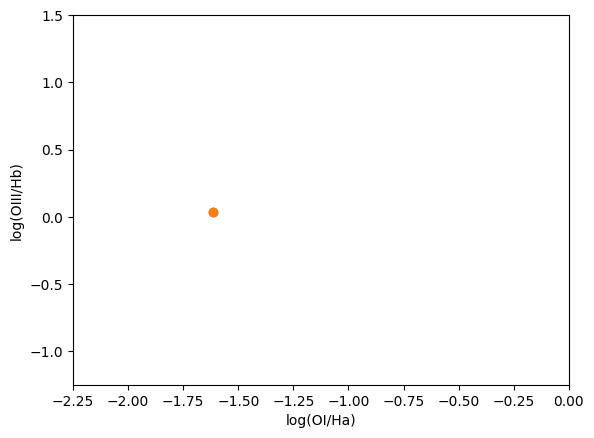

In [71]:
# Plot O1-BPT diagram
plt.scatter(np.log10(em_fluxes_r1['OI']/em_fluxes_r1['Ha']),np.log10(em_fluxes_r1['OIII_2']/em_fluxes_r1['Hb'])) # plot region 1
plt.scatter(np.log10(em_fluxes_r2['OI']/em_fluxes_r2['Ha']),np.log10(em_fluxes_r2['OIII_2']/em_fluxes_r2['Hb'])) # plot region 2
plt.xlim(-2.25,0.0) # common limits for O1-BPT diagram
plt.ylim(-1.25,1.5) # common limits for O1-BPT diagram
plt.xlabel(r'log(OI/Ha)')
plt.ylabel(r'log(OIII/Hb)')
plt.show()

Cool. Now we have two points on a graph. Meaningless right now. These BPT diagrams only work becase different types of objects occupy different areas of these diagrams. So we need to actually know where things are expected to be. The classical empirical demarcations come from Kauffmann et al. 2003 and Kewley et al. 2001. 

__Find these _very highly cited_ papers on ADS and we will use them to draw some lines on our plots.__

Kauffmann et al. 2003 has only a relation for the N2-BPT diagram, but the Kewley et al. 2001 paper has all three diagnostics. 
Use the equations provided in both papers to define functions that take an X array and return a Y array.

*Hint: check page 4 of Kauffmann et al. 2003 and page 17 of Kewley et al. 2001 for equations*


In [72]:
def kewley_N2O3(N2):
    O3=0.61/(N2-0.47) + 1.19
    return O3

def kewley_S2O3(S2):
    O3=0.72/(S2-0.32) + 1.30
    return O3

def kewley_O1O3(O1):
    O3=0.73/(O1+0.59) + 1.33
    return O3

def kauffmann_N2O3(N2):
    O3=0.61/(N2-0.05) + 1.30
    return O3

### What do these lines tell us? What does it mean to be above or below these lines?

Now let's try plotting these lines on the BPT diagrams we made. Let's also make this figure look nice, so we'll put all three diagrams together into a subplot. 

Remember that there are 2 lines that go on the N2-BPT diagram, but only one for the other two plots. 

In [ ]:
fig,axs=plt.subplots(1,3,figsize=(14,5),sharey=True) # all panels have the same y axis, only label the outer panels
plt.subplots_adjust(wspace=0) # changes the width spacing between the panels
# hspace would change the height space

# Plot N2-BPT diagram
axs[0].scatter(__) # plot region 1
axs[0].scatter(__) # plot region 2

axs[0].plot(np.linspace(-2,0.3,1000),kewley_N2O3(np.linspace(-2,0.3,1000)),color=__,label='Ke01')
axs[0].plot(np.linspace(-2,0,1000),kauffmann_N2O3(np.linspace(-2,0,1000)),color=__,ls='--',label='Ka03')
axs[0].legend()

axs[0].set_xlim(__) # common limits for N2-BPT diagram
axs[0].set_ylim(__) # common limits for N2-BPT diagram
axs[0].set_xlabel(r'__',fontsize=15)
axs[0].set_ylabel(r'__',fontsize=15)


# Plot S2-BPT diagram
__

axs[1].plot(___,kewley_S2O3(___),color=__,label='Ke01')

axs[1].set_xlim(__) # common limits for S2-BPT diagram
axs[1].set_xlabel(r'__',fontsize=15)


# Plot O1-BPT diagram
__


plt.show()

Weird things happen in both functions if you plot the function with too high of an N2 value. So if things don't look smooth, try reducing the upper limit of your x array for plotting the line (right before the weird behavior on the x axis should fix things!)

But this is super cool right? Region 1 and Region 2 are definitely separated on all of these plots. 


### What conclusions can you draw about both regions based on where they lie on these diagrams?

## Comparison to Literature

There are several different types of objects that rely on these BPT diagrams for classification:
1. HII regions,
2. planetary nebulae,
3. supernova remnants,
4. active galactic nuclei (AGN, LINERS, Seyferts, etc)

We can basically definitely rule out any form of AGN just visually because these regions are very small and isolated compared to what we would expect from an AGN-powered region. And based on the fact that NGC1300 doesn't even have an AGN. So that leaves us with three options. All three of these options rely on star formation processes and so they typically all lie close to or below the Kewley and Kauffman lines. AGN would be way up in the top right corner. 

Let's check the literature to really see how these are distinguished between each other. We will use Jing Li et al 2024, Enrico Congiu et al. 2025, and Brent Groves et al. 2023. **You have already found Li et al. and Groves et al., now find Congiu et al.**


### Find the selection criteria for the regions of interest in each paper.

### Groves et al. 2023
Section 4.2, page 8: 


### Congiu et al. 2025
Section 3.4, page 7: 


### Li et al. 2024
This paper uses 5 different criteria to select their sample. But focus on Section 3.2, and particularly page 11 and the parts relating directly to emission line ratio values. Also look at Figure 6. It is also important to note that this paper does _not_ take the log of any of their ratio values like we have been. 

### Answers
Only reveal if you are stuck! Ask questions if you need help.

#### Groves et al. 2023
Section 4.2, page 8: 

Classical BPT diagnostics, HII regions are identified as nebulae below the Kewley AND Kauffmann lines in all three diagrams

#### Congiu et al. 2025
Section 3.4, page 7: 
$$\log_{10}\frac{I_{\rm [SII]\lambda 6717 + [SII]\lambda 6731}}{I_{\rm H\alpha}} > -0.4$$
This means that planetary nebulae have to have [SII]/H$\alpha$ < -0.4
$$\log_{10}\frac{I_{5007}}{I_{\rm H\alpha+[NII]\lambda 6583}} > -0.37M_{5007}-1.16$$
This one is a lot more complicated and requires converting the measured OIII flux to a magnitude, $M_{5007}$. 
But ultimately, this means that [OIII]$\lambda 5007$ is almost always brighter than H$\alpha$. This translates to an [OIII]$\lambda 5007$/H$\beta$ ratio greater than 0.45.

#### Li et al. 2024
This paper uses 5 different criteria to select their sample. But focus on Section 3.2, and particularly page 11 and the parts relating directly to emission line ratio values. Also look at Figure 6. It is also important to note that this paper does _not_ take the log of any of their ratio values like we have been. 
$$\rm [OI]/H\alpha > 0.1$$
$$\rm [SII]/H\alpha > 0.4$$

and in log space, this is
$$\rm \log_{10}([OI]/H\alpha) > -1$$
$$\rm \log{10}([SII]/H\alpha) > -0.4$$

Okay now back to coding. Let's try to shade different regions of the BPT diagrams with where the different regions lie. For this we will use the function 'plt.fill_between' (https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.fill_between.html)
This function takes in an x array over which the area will be shaded, y1 as the bottom y value and y2 as the top. y1 and y2 can both be curves as well. But let's just try it with the HII region criteria from Groves et al. 

### Add the following block of code to your plotting code for the BPT diagrams
This block shades the region between some lower limit that I arbitrarily decided to be -2 and the curve defined by our kewley and kauffmann functions.

In [ ]:
x=np.linspace(-2,0,1000) # same x array over which the relevant curve is plotted
y1=-2
y2=kauffmann_N2O3(x) # strictest requirement for the N2-BPT diagram
axs[0].fill_between(x,y1,y2,color='gray')
x=np.linspace(-2,0.3,1000)
y1=-2
y2=kewley_S2O3(x) # only diagnostic curve on this diagram
axs[1].fill_between(x,y1,y2,color='gray')
x=np.linspace(-2.5,-0.7,1000)
y1=-2
y2=kewley_O1O3(x)
axs[2].fill_between(x,y1,y2,color='gray')

Play around with the 'color' keyword and choose a color you like. You can also change the transparency of the shading with 'alpha' keyword where 'alpha=1' is the default fully opaque. I usually use 'alpha=0.3' for a light shading. 

We will be shading regions of every diagram for the three different types of regions, so keep all HII region shadings one color, all SNR shadings a different color, and all PNe shadings a third color. 

In [ ]:
# plot your BPT diagrams with the HII regions shaded here

Now try to define the requirements for the other types of regions and shade the corresponding regions on each of the BPT diagrams. You can also write these fill_between functions in one line like: 

    axs[0].fill_between(np.linspace(-2,0,1000),-2,kauffmann_N2O3(np.linspace(-2,0,1000)),color='gray')

Plot these regions on your BPT diagrams. Make this a well-designed plot, with everything labeled and legible. This figure will be your main result. Don't forget to save it!

In [ ]:
fig,axs=plt.subplots(1,3,figsize=(14,5),sharey=True)
plt.subplots_adjust(wspace=0)
# Plot N2-BPT diagram
__

axs[0].plot(__,label='Ke01')
axs[0].plot(__,label='Ka03')
axs[0].legend(fontsize=14)

axs[0].fill_between(__)
axs[0].fill_between(__)

axs[0].set_xlim(__)
axs[0].set_ylim(__)
axs[0].set_xlabel(__)
axs[0].set_ylabel(__)


# Plot S2-BPT diagram
__

axs[1].fill_between(__)
axs[1].text(__,'HII Regions',__) # add label to define each shaded region
axs[1].fill_between(__)
axs[1].text(__,'SNRs',__) # add label to define each shaded region
axs[1].fill_between(__)
axs[1].text(__,'PNe',__) # add label to define each shaded region

axs[1].set_xlim(__)
axs[1].set_xlabel(__)


# Plot O1-BPT diagram
__

plt.savefig(__)
plt.show()

This is a super cool plot! Now let's interpret these final results!

### What is Region 1?

### What is Region 2?